Відрізок 1:
S_0(x) = 1.54 + 5.8638(x-0.5) + 0.0(x-0.5)^2 + -7.8986(x-0.5)^3
Відрізок 2:
S_1(x) = 3.38 + 2.0724(x-0.9) + -9.4783(x-0.9)^2 + 6.1053(x-0.9)^3
Відрізок 3:
S_2(x) = 2.53 + -2.7079(x-1.5) + 1.5111(x-1.5)^2 + 1.0336(x-1.5)^3
Відрізок 4:
S_3(x) = 1.86 + 1.6944(x-2.3) + 3.9917(x-2.3)^2 + -1.9008(x-2.3)^3


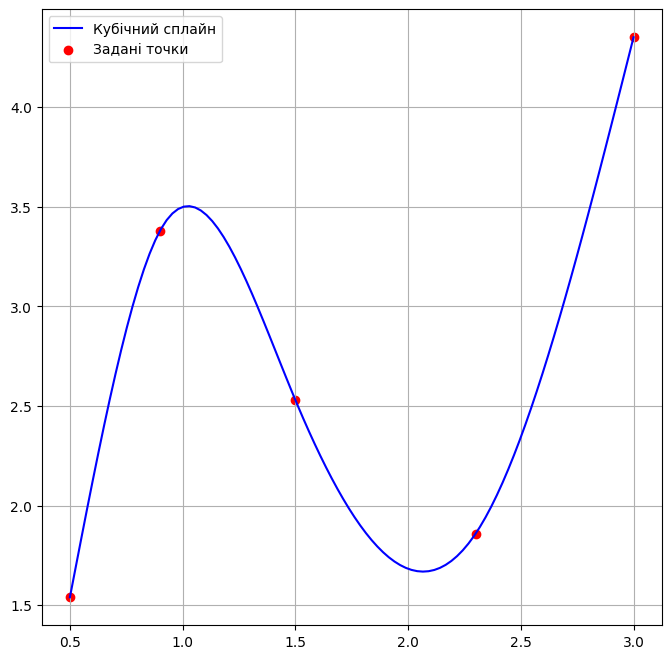

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([0.5, 0.9, 1.5, 2.3, 3.0])
y = np.array([1.54, 3.38, 2.53, 1.86, 4.35])

n = len(x) - 1
h = np.diff(x)
a = y

alpha = np.zeros(n)
for i in range(1, n):
    alpha[i] = (3/h[i])*(a[i+1]-a[i]) - (3/h[i-1])*(a[i]-a[i-1])

l = np.ones(n+1)
mu = np.zeros(n)
z = np.zeros(n+1)

for i in range(1, n):
    l[i] = 2*(x[i+1]-x[i-1]) - h[i-1]*mu[i-1]
    mu[i] = h[i]/l[i]
    z[i] = (alpha[i] - h[i-1]*z[i-1])/l[i]

l[n] = 1
z[n] = 0
c = np.zeros(n+1)
b = np.zeros(n)
d = np.zeros(n)

for j in range(n-1, -1, -1):
    c[j] = z[j] - mu[j]*c[j+1]
    b[j] = (a[j+1]-a[j])/h[j] - h[j]*(c[j+1] + 2*c[j])/3
    d[j] = (c[j+1]-c[j])/(3*h[j])

for i in range(n):
    print(f"Відрізок {i+1}:")
    print(f"S_{i}(x) = {a[i]} + {b[i].round(4)}(x-{x[i]}) + {c[i].round(4)}(x-{x[i]})^2 + {d[i].round(4)}(x-{x[i]})^3")

x_vals = np.linspace(np.min(x), np.max(x), 100)
y_vals = []
for i in range(n):
    mask = (x_vals >= x[i]) & (x_vals <= x[i+1])
    xi = x_vals[mask]
    yi = a[i] + b[i]*(xi-x[i]) + c[i]*(xi-x[i])**2 + d[i]*(xi-x[i])**3
    y_vals.extend(yi)

plt.figure(figsize=(8,8))
plt.plot(x_vals, y_vals, label="Кубічний сплайн", color='b')
plt.scatter(x, y, label="Задані точки", color='r')
plt.grid()
plt.legend()
plt.show()

Результати CubicSpline():
S_1(x) = -7.8986*(x-0.5)^3 + 0.0000*(x-0.5)^2 + 5.8638*(x-0.5) + 1.54
S_2(x) = 6.1053*(x-0.9)^3 + -9.4783*(x-0.9)^2 + 2.0724*(x-0.9) + 3.38
S_3(x) = 1.0336*(x-1.5)^3 + 1.5111*(x-1.5)^2 + -2.7079*(x-1.5) + 2.53
S_4(x) = -1.9008*(x-2.3)^3 + 3.9917*(x-2.3)^2 + 1.6944*(x-2.3) + 1.86


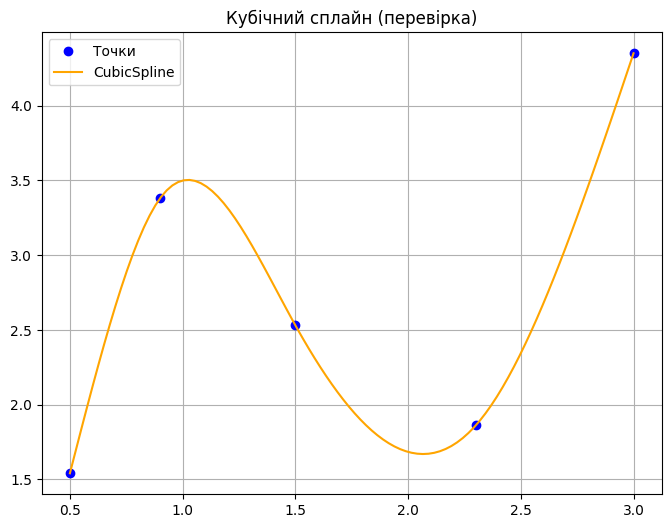

In [ ]:
import numpy as np
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt

x = np.array([0.5, 0.9, 1.5, 2.3, 3.0])
y = np.array([1.54, 3.38, 2.53, 1.86, 4.35])

cs = CubicSpline(x, y, bc_type='natural')

print("Результати CubicSpline():")
for i in range(len(x)-1):
    coeffs = cs.c[:, i]
    spline = f'S_{i+1}(x) = {coeffs[0]:.4f}*(x-{x[i]})^3 + {coeffs[1]:.4f}*(x-{x[i]})^2 + {coeffs[2]:.4f}*(x-{x[i]}) + {y[i]}'
    print(spline)

x_new = np.linspace(np.min(x), np.max(x), 100)
plt.figure(figsize=(8,6))
plt.plot(x, y, 'o', label='Точки', color='blue')
plt.plot(x_new, cs(x_new), label='CubicSpline', color='orange')
plt.title('Кубічний сплайн (перевірка)')
plt.grid(True)
plt.legend()
plt.show()